In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
cheaters_path = Path("../data/cheaters/cheaters.npy")
legit_path = Path("../data/legit/legit.npy")

cheaters = np.load(cheaters_path)
legit = np.load(legit_path)

print(f"cheaters: shape={cheaters.shape}, dtype={cheaters.dtype}")
print(f"legit:    shape={legit.shape}, dtype={legit.dtype}")

cheaters_mb = cheaters.nbytes / (1024 ** 2)
legit_mb = legit.nbytes / (1024 ** 2)
print(f"cheaters size: {cheaters_mb:.2f} MB")
print(f"legit size:    {legit_mb:.2f} MB")

cheaters: shape=(2000, 30, 192, 5), dtype=float32
legit:    shape=(10000, 30, 192, 5), dtype=float32
cheaters size: 219.73 MB
legit size:    1098.63 MB


In [3]:
X = np.concatenate([cheaters, legit], axis=0)
y = np.concatenate([
    np.ones(cheaters.shape[0], dtype=np.int64),
    np.zeros(legit.shape[0], dtype=np.int64),
])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"class {label}: {count}")

X shape: (12000, 30, 192, 5)
y shape: (12000,)
class 0: 10000
class 1: 2000


In [4]:
channel_names = [
    "AttackerDeltaYaw",
    "AttackerDeltaPitch",
    "CrosshairToVictimYaw",
    "CrosshairToVictimPitch",
    "Firing",
]

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"NaN count: {nan_count}")
print(f"Inf count: {inf_count}")

for i, name in enumerate(channel_names):
    channel_data = X[..., i]
    print(f"{name}: min={channel_data.min()}, max={channel_data.max()}")

NaN count: 0
Inf count: 0
AttackerDeltaYaw: min=-180.0, max=179.86300659179688


AttackerDeltaPitch: min=-98.60199737548828, max=96.93800354003906
CrosshairToVictimYaw: min=-180.0, max=180.0


CrosshairToVictimPitch: min=-154.13299560546875, max=119.46099853515625
Firing: min=0.0, max=1.0


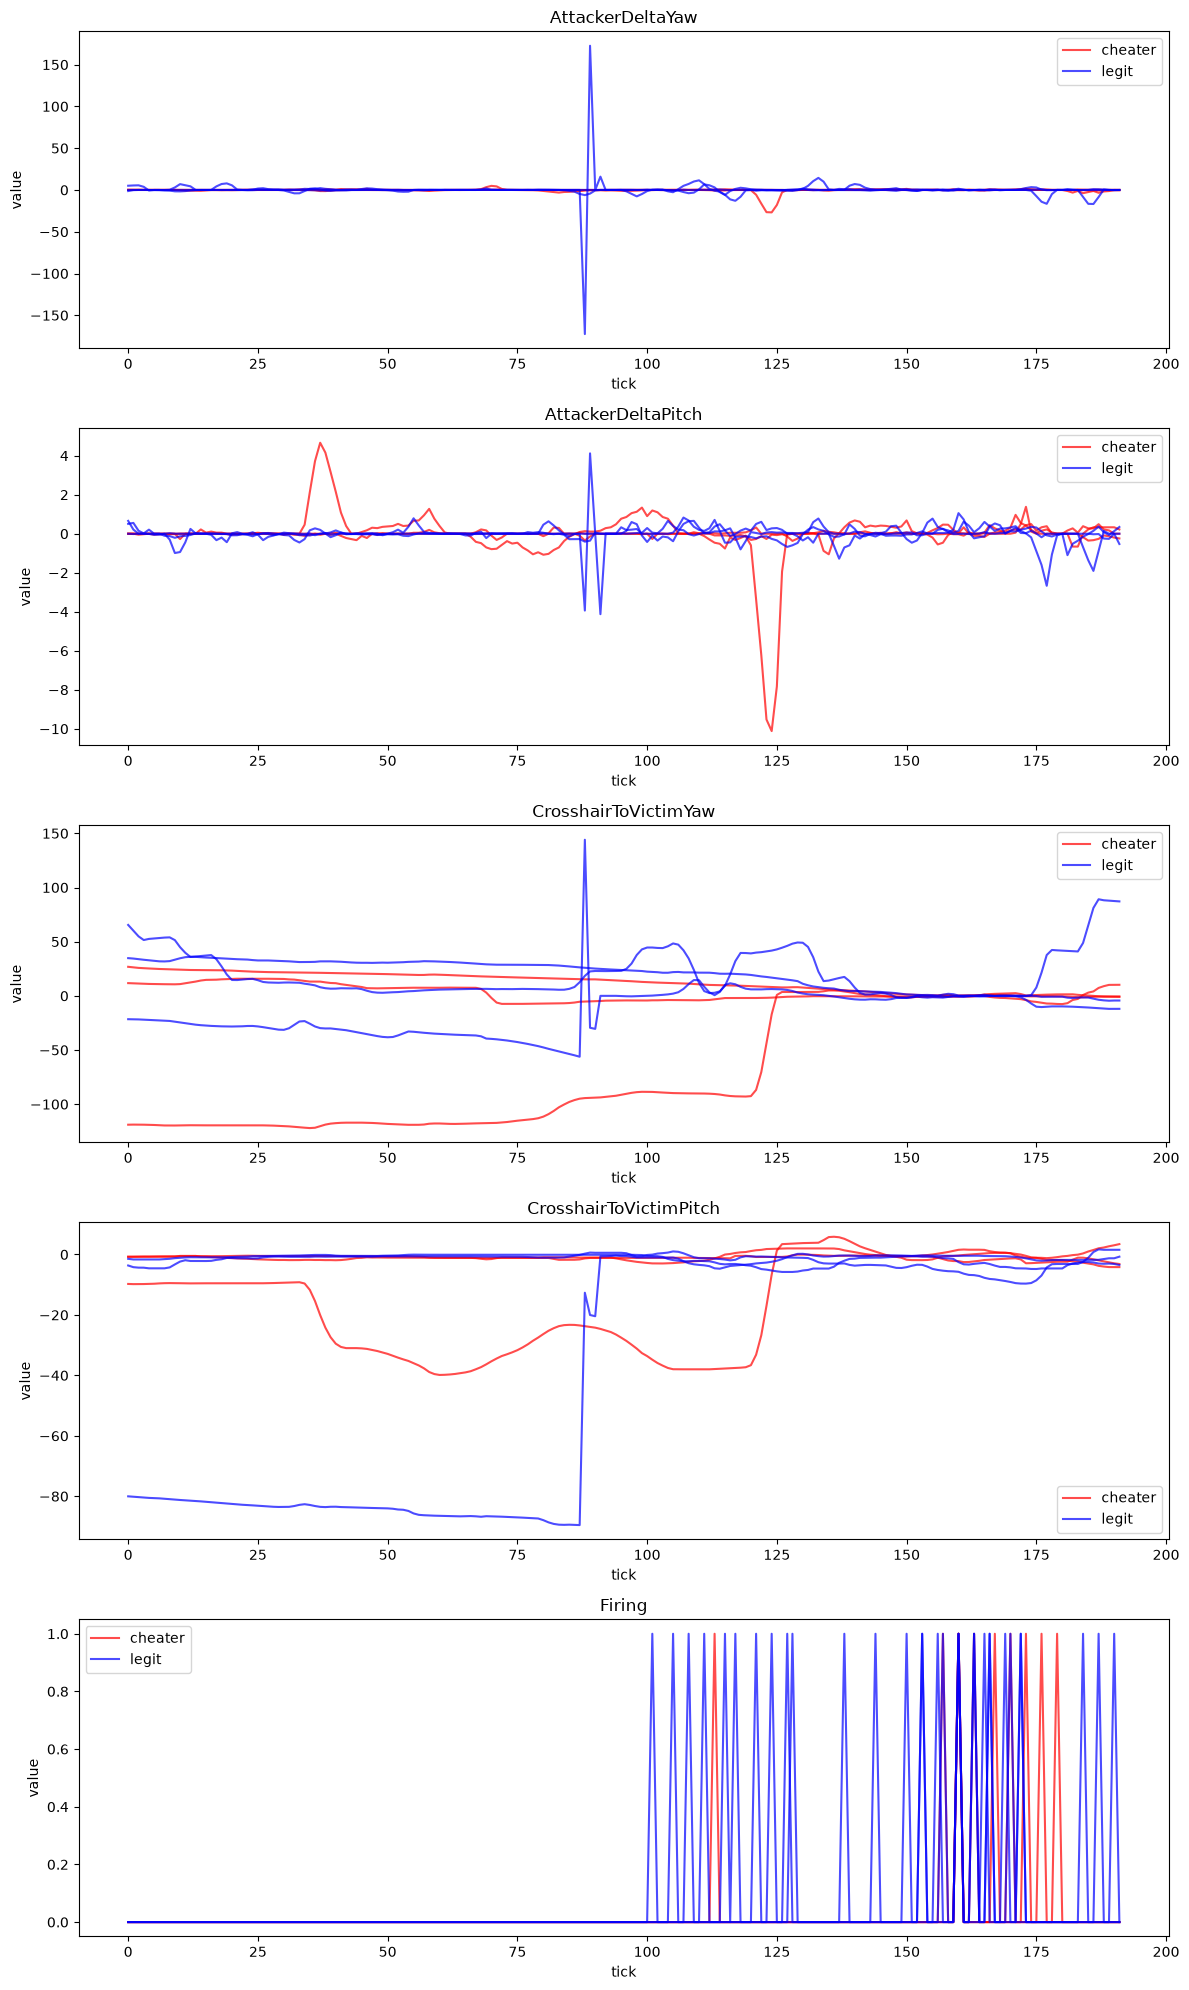

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(12, 20))

engagement_idx = 0
player_indices = [0, 1, 2]

for i, name in enumerate(channel_names):
    ax = axes[i]
    for p in player_indices:
        ax.plot(cheaters[p, engagement_idx, :, i], color="red", alpha=0.7,
                label="cheater" if p == 0 else None)
    for p in player_indices:
        ax.plot(legit[p, engagement_idx, :, i], color="blue", alpha=0.7,
                label="legit" if p == 0 else None)
    ax.set_title(name)
    ax.set_xlabel("tick")
    ax.set_ylabel("value")
    ax.legend()

plt.tight_layout()
plt.savefig("eda_raw_traces.png")
plt.show()

In [6]:
total = len(y)
cheater_count = int((y == 1).sum())
legit_count = int((y == 0).sum())
cheater_pct = cheater_count / total * 100
legit_pct = legit_count / total * 100

print(f"cheater count: {cheater_count} ({cheater_pct:.2f}%)")
print(f"legit count:   {legit_count} ({legit_pct:.2f}%)")
print()
print(
    "Class imbalance statement: the dataset is imbalanced roughly 1:5 "
    "(cheaters:legit), so raw accuracy is a misleading metric — a model "
    "predicting 'legit' for everyone would score ~83% accuracy while "
    "catching zero cheaters. Precision, recall, F1, and PR-AUC (or ROC-AUC) "
    "should be used instead, and class weighting/resampling should be "
    "considered during training."
)

cheater count: 2000 (16.67%)
legit count:   10000 (83.33%)

Class imbalance statement: the dataset is imbalanced roughly 1:5 (cheaters:legit), so raw accuracy is a misleading metric — a model predicting 'legit' for everyone would score ~83% accuracy while catching zero cheaters. Precision, recall, F1, and PR-AUC (or ROC-AUC) should be used instead, and class weighting/resampling should be considered during training.
